In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RSEED = 42

In [113]:
df_delayed_flights = pd.read_csv("data/Train.csv")

In [114]:
df_delayed_flights.columns = ["ID", "flight_date", "flight_number", "airport_departure", "airport_arrival", "sch_time_dep", "sch_time_arr", "status", "aircraft_code", "delay"]
df_delayed_flights["sch_time_dep"] = pd.to_datetime(df_delayed_flights["sch_time_dep"])
df_delayed_flights["sch_time_dep"] = df_delayed_flights["sch_time_dep"].astype("datetime64[ns]")

df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].str.replace(".", ":")
df_delayed_flights["sch_time_arr"] = pd.to_datetime(df_delayed_flights["sch_time_arr"])
df_delayed_flights["sch_time_arr"] = df_delayed_flights["sch_time_arr"].astype("datetime64[ns]")

df_delayed_flights["sch_time_dep_hour"] = df_delayed_flights["sch_time_dep"].dt.hour
df_delayed_flights["sch_time_dep_day"] = df_delayed_flights["sch_time_dep"].dt.day
df_delayed_flights["sch_time_dep_month"] = df_delayed_flights["sch_time_dep"].dt.month


In [115]:
df_delayed_flights.columns

Index(['ID', 'flight_date', 'flight_number', 'airport_departure',
       'airport_arrival', 'sch_time_dep', 'sch_time_arr', 'status',
       'aircraft_code', 'delay', 'sch_time_dep_hour', 'sch_time_dep_day',
       'sch_time_dep_month'],
      dtype='object')

In [116]:
print("What is the average delay for all flights?")
print(round(df_delayed_flights["delay"].mean(),3))
print("What is the average delay for delayed flights?")
print(df_delayed_flights[df_delayed_flights["delay"] > 0.0]["delay"].mean())

What is the average delay for all flights?
48.733
What is the average delay for delayed flights?
75.43281418215747


In [117]:
df_abc = df_delayed_flights.copy()
df_abc['sch_dep_hour'] = df_abc['sch_time_dep'].dt.hour
df_abc_new = df_abc[(df_abc["sch_dep_hour"] >= 7) & (df_abc["sch_dep_hour"] <= 10)]
print("What is the average delay for all flights?")
print(round(df_abc_new["delay"].mean(),3))
print("What is the average delay for delayed flights?")
print(df_abc_new[df_abc_new["delay"] > 0.0]["delay"].mean())

What is the average delay for all flights?
36.883
What is the average delay for delayed flights?
54.967516143343026


In [118]:
# Predict the percentage of delayed flights in the morning between 7 am and 10 am
delays = int(df_abc_new[df_abc_new["delay"] > 0.0].shape[0])
no_delays = int(df_abc_new[df_abc_new["delay"] == 0.0].shape[0])
overall = int(df_abc_new["delay"].shape[0])

print("Flights with delay: " + str(round((delays) * 100 / overall,2)) + " %")
print("Flights without delay: " + str(round((no_delays) * 100 / overall,2)) + " %")

Flights with delay: 67.1 %
Flights without delay: 32.9 %


In [119]:
print("Top ten airport delay distributed by raw delay time")
print("How many flights are delayed?")
print(df_delayed_flights["delay"].shape[0])
print("How many Delays have a time of more then 2 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 120.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 120.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 4 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 240.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 240.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 8 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 480.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 480.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")

Top ten airport delay distributed by raw delay time
How many flights are delayed?
107833
How many Delays have a time of more then 2 hours?
12447
11.5%
How many Delays have a time of more then 4 hours?
4729
4.3999999999999995%
How many Delays have a time of more then 8 hours?
1234
1.0999999999999999%


In [120]:
# Remove Outliers
df_delayed_flights = df_delayed_flights[df_delayed_flights["delay"] < 240.0]
df_delayed_flights.shape[0]

102999

In [121]:
# df_delayed_flights["delay"] = df_delayed_flights.delay.apply(lambda x: np.log(x))
# df_delayed_flights.delay.describe().T

In [122]:
print("Top ten airport delay distributed by raw delay time")
print("How many flights are delayed?")
print(df_delayed_flights["delay"].shape[0])
print("How many Delays have a time of more then 2 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 120.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 120.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 4 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 240.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 240.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")
print("How many Delays have a time of more then 8 hours?")
print(df_delayed_flights[df_delayed_flights["delay"] > 480.0].shape[0])
print(str(round(int(df_delayed_flights[df_delayed_flights["delay"] > 480.0].shape[0]) / int(df_delayed_flights["delay"].shape[0]),3) * 100) + "%")

Top ten airport delay distributed by raw delay time
How many flights are delayed?
102999
How many Delays have a time of more then 2 hours?
7613
7.3999999999999995%
How many Delays have a time of more then 4 hours?
0
0.0%
How many Delays have a time of more then 8 hours?
0
0.0%


In [123]:
# Balance of flights with delay and without delay
raw_data_delays = int(df_delayed_flights[df_delayed_flights["delay"] > 0.0].shape[0])
raw_data_no_delays = int(df_delayed_flights[df_delayed_flights["delay"] == 0.0].shape[0])
raw_data_overall = int(df_delayed_flights["delay"].shape[0])

print("Flights with delay: " + str(round((raw_data_delays) * 100 / raw_data_overall,2)) + " %")
print("Flights without delay: " + str(round((raw_data_no_delays) * 100 / raw_data_overall,2)) + " %")

Flights with delay: 62.94 %
Flights without delay: 37.06 %


In [124]:
top_ten_dep_airports = df_delayed_flights["airport_departure"].value_counts().head(10).index.tolist()
print(top_ten_dep_airports)

top_ten_arr_airports = df_delayed_flights["airport_arrival"].value_counts().head(10).index.tolist()
print(top_ten_arr_airports)


['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'MXP', 'ALG', 'FRA']
['TUN', 'DJE', 'ORY', 'MIR', 'MRS', 'LYS', 'NCE', 'MXP', 'ALG', 'FRA']


In [125]:
df_delayed_flights = df_delayed_flights[df_delayed_flights["airport_departure"].isin(top_ten_dep_airports) & df_delayed_flights["airport_arrival"].isin(top_ten_arr_airports)]
df_delayed_flights.airport_departure.value_counts(ascending=False)
df_delayed_flights.airport_arrival.value_counts(ascending=False)

df_delayed_flights.airport_arrival.value_counts()

airport_arrival
TUN    21098
DJE     7115
ORY     6358
MIR     3297
MRS     2658
LYS     2172
NCE     2131
MXP     1466
ALG     1438
FRA     1236
Name: count, dtype: int64

In [126]:
df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(top_ten_dep_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(top_ten_arr_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
df_delayed_flights.airport_departure.value_counts()
df_delayed_flights.airport_arrival.value_counts()

/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_54541/2570058211.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_departure"] = df_delayed_flights["airport_departure"].replace(top_ten_dep_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_54541/2570058211.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["airport_arrival"] = df_delayed_flights["airport_arrival"].replace(top_ten_arr_airports, [1, 2, 3, 4, 5, 6, 7, 8, 9,

airport_arrival
1     21098
2      7115
3      6358
4      3297
5      2658
6      2172
7      2131
8      1466
9      1438
10     1236
Name: count, dtype: int64

In [127]:
#df_delayed_flights.aircraft_code.value_counts()
df_delayed_flights['aircraft_type'] = df_delayed_flights['aircraft_code'].str[3:].str[:3]

In [128]:
df_delayed_flights = df_delayed_flights.query("status != 'RTR'")

In [129]:
df_delayed_flights["status"].value_counts()

status
ATA    38635
SCH    10017
DEL       64
DEP       13
Name: count, dtype: int64

In [130]:
df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "DEL"], [1, 2, 3, 4])
df_delayed_flights["status"].value_counts()

/var/folders/8w/dmpm9m8525x38x65g4z96bsm0000gn/T/ipykernel_54541/3589274579.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delayed_flights["status"] = df_delayed_flights["status"].replace(["ATA", "SCH", "DEP", "DEL"], [1, 2, 3, 4])


status
1    38635
2    10017
4       64
3       13
Name: count, dtype: int64

<Axes: >

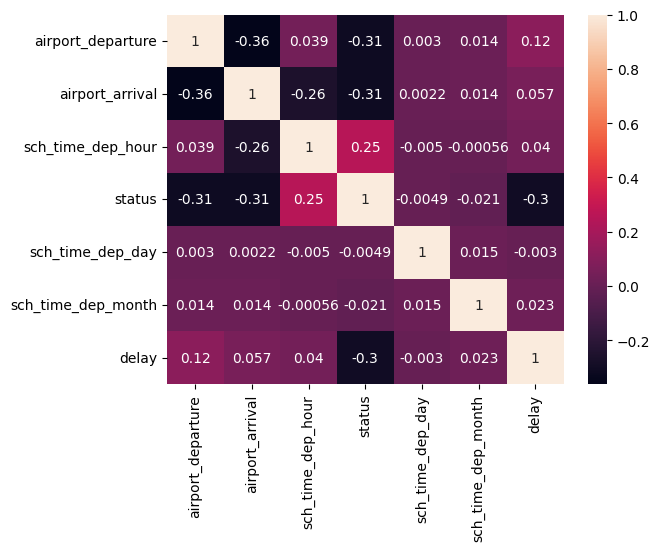

In [131]:
sns.heatmap(data=df_delayed_flights[["airport_departure", "airport_arrival", "sch_time_dep_hour", "status", "sch_time_dep_day", "sch_time_dep_month", "delay"]].corr(), annot=True)

In [132]:
# airport_arrival, airport_departure, status, dep_hour, dep_month
df_delayed_flights = pd.get_dummies(df_delayed_flights, columns=["airport_arrival", "airport_departure", "status", "sch_time_dep_hour","aircraft_type"], drop_first=True)
df_delayed_flights.columns

Index(['ID', 'flight_date', 'flight_number', 'sch_time_dep', 'sch_time_arr',
       'aircraft_code', 'delay', 'sch_time_dep_day', 'sch_time_dep_month',
       'airport_arrival_2', 'airport_arrival_3', 'airport_arrival_4',
       'airport_arrival_5', 'airport_arrival_6', 'airport_arrival_7',
       'airport_arrival_8', 'airport_arrival_9', 'airport_arrival_10',
       'airport_departure_2', 'airport_departure_3', 'airport_departure_4',
       'airport_departure_5', 'airport_departure_6', 'airport_departure_7',
       'airport_departure_8', 'airport_departure_9', 'airport_departure_10',
       'status_2', 'status_3', 'status_4', 'sch_time_dep_hour_1',
       'sch_time_dep_hour_2', 'sch_time_dep_hour_3', 'sch_time_dep_hour_4',
       'sch_time_dep_hour_5', 'sch_time_dep_hour_6', 'sch_time_dep_hour_7',
       'sch_time_dep_hour_8', 'sch_time_dep_hour_9', 'sch_time_dep_hour_10',
       'sch_time_dep_hour_11', 'sch_time_dep_hour_12', 'sch_time_dep_hour_13',
       'sch_time_dep_hour_14', 'sc

## Train test split

In [133]:
#columns_to_scale = ["airport_departure", "airport_arrival", "sch_time_dep_hour", "sch_time_dep_day", "sch_time_dep_month",  "status"]
columns_to_drop = ["ID", "flight_date", "flight_number", "aircraft_code", "sch_time_dep", "sch_time_arr", "sch_time_dep_month", "sch_time_dep_day", "delay"]

X = df_delayed_flights.drop(columns_to_drop, axis=1)
y = df_delayed_flights["delay"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RSEED)

df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [134]:
X_test.shape[0]

12183

## Baseline model

All flights with departure time between 7 am and 10 am have a delay, as we assume that in the morning rush hour there will be a lot of flights leaving and this will have a negative influence on the punctuality.

In [135]:
def baseline_model(row):
    
    columns_list = ['sch_time_dep_hour_7', 'sch_time_dep_hour_8', 'sch_time_dep_hour_9', 'sch_time_dep_hour_10']
    
    if any(row[col] for col in columns_list):
        return 15.0
    else:
        return 0.0
    
# Apply baseline model to each row in the DataFrame
y_train_pred_baseline = df_train.apply(baseline_model, axis=1)
y_test_pred_baseline = df_test.apply(baseline_model, axis=1)

In [136]:
# eigentlich ohne drop_first
# True, False, False
# mit drop_first
# True, False -> weil das letzte False sowieso False sein, weil es bereits True gab

In [137]:
# Predict the percentage of delayed flights in the morning between 7 am and 10 am
df_base = df_test[(df_test["sch_time_dep_hour_7"] == True) | (df_test["sch_time_dep_hour_8"] == True) | (df_test["sch_time_dep_hour_9"] == True) | (df_test["sch_time_dep_hour_10"] == True)]

delays = int(df_base[df_base["delay"] > 0.0].shape[0])
no_delays = int(df_base[df_base["delay"] == 0.0].shape[0])
overall = int(df_base["delay"].shape[0])

print("Flights with delay: " + str(round((delays) * 100 / overall,2)) + " %")
print("Flights without delay: " + str(round((no_delays) * 100 / overall,2)) + " %")

Flights with delay: 65.66 %
Flights without delay: 34.34 %


In [138]:
print(y_test_pred_baseline.head())
baseline_pred_delays = int(y_test_pred_baseline[y_test_pred_baseline == 15.0].shape[0])
baseline_pred_no_delays = int(y_test_pred_baseline[y_test_pred_baseline == 0.0].shape[0])
baseline_pred_overall = int(y_test_pred_baseline.shape[0])

print("Flights with delay: " + str(round((baseline_pred_delays) * 100 / baseline_pred_overall,2)) + " %")
print("Flights without delay: " + str(round((baseline_pred_no_delays) * 100 / baseline_pred_overall,2)) + " %")

# 3 -> 1/5 von 15

baseline_pred_sum_delays = y_test_pred_baseline.sum()
baseline_pred_mean_delay = y_test_pred_baseline.mean()
print("The mean delay predicted for the baseline models contains " + str(baseline_pred_delays) + " delays with an average of " + str(round(baseline_pred_mean_delay,0)))

54386      0.0
47338      0.0
102820    15.0
60171      0.0
10251     15.0
dtype: float64
Flights with delay: 27.68 %
Flights without delay: 72.32 %
The mean delay predicted for the baseline models contains 3372 delays with an average of 4.0


In [139]:
# Calculate the Root Mean Squared Error for our baseline model
print("Mean Squared Error for Train:", round(root_mean_squared_error(y_train, y_train_pred_baseline), 3))
print("Mean Squared Error for Test:", round(root_mean_squared_error(y_test, y_test_pred_baseline), 3))
# Calculate the R-squared for our baseline model
print("R-squared for Train:", round(r2_score(y_train, y_train_pred_baseline), 3))
print("R-squared for Test:", round(r2_score(y_test, y_test_pred_baseline), 3))

Mean Squared Error for Train: 49.44
Mean Squared Error for Test: 50.388
R-squared for Train: -0.289
R-squared for Test: -0.29


## Using the standard scaler

In [140]:
# scaler = StandardScaler()

# # Fit & Transform: Calculate mean/standard deviation und transform
# df_delayed_flights[columns_to_scale] = scaler.fit_transform(df_delayed_flights[columns_to_scale])

# # Important: apply only .transform() on the test set, not fit !!!
# df_delayed_flights[columns_to_scale] = scaler.transform(df_delayed_flights[columns_to_scale])

## Linear Regression model

In [141]:
lin_reg = LinearRegression().fit(X_train, y_train)

y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)
y_pred_train = np.clip(y_pred_train, 0, None).round(0)
y_pred_test = np.clip(y_pred_test, 0, None).round(0)

In [142]:
print(lin_reg.intercept_, lin_reg.coef_)

35.35006978948741 [ -1.06412718   7.35359216  -2.77868585  11.69627571  13.11848747
   8.77376485  11.94612058   9.17732743   4.35847492  -5.05507832
  11.415938   -10.10145358   9.9921328   17.05856436   1.92879112
   3.71010868   9.54795162   6.89491612 -24.14242325 -16.13573572
 -26.88827688  -0.43519896  -7.26714444  -5.32029819  -1.02225762
  -3.79080951  -9.43717143  -6.91030186  -8.31939757  -0.55536568
  -0.30958859   4.31959288   8.63694757   8.15821821  12.08113403
   8.34286842  17.20322025   9.75250301   3.65172394  11.51262496
   5.36446804   8.36167818   2.25785709  -1.06835993 -17.77839822
 -20.55945496  -9.52855013 -10.86182674   0.42793364  33.66481059
 103.87448313 -11.58507004  15.4725328  -19.05429571  13.24658219
 -12.72865965 -11.38769002 -15.73021824]


In [143]:
#sns.pairplot(df_train);

In [144]:
print("Train Mean and Median:")
print(round(df_train.delay.mean(),2))
print(round(df_train.delay.median(),2))

print("Test Mean and Median:")
print(round(df_test.delay.mean(),2))
print(round(df_test.delay.median(),2))

Train Mean and Median:
26.24
9.0
Test Mean and Median:
26.59
9.0


In [145]:
# Calculate the Root Mean Squared Error for our linear regression model
print("Mean Squared Error for Train:", round(root_mean_squared_error(y_train, y_pred_train), 3))
print("Mean Squared Error for Test:", round(root_mean_squared_error(y_test, y_pred_test), 3))
# Calculate the R-squared for our linear regression model
print("R-squared:", round(r2_score(y_train, y_pred_train), 3))
print("R-squared:", round(r2_score(y_test, y_pred_test), 3))

Mean Squared Error for Train: 39.567
Mean Squared Error for Test: 40.533
R-squared: 0.174
R-squared: 0.165


In [146]:
test = pd.DataFrame(y_pred_test)
test.info()
test.describe().T
#test_set = int(test[test == 0.0].shape[0])
#test_set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12183 entries, 0 to 12182
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       12183 non-null  float64
dtypes: float64(1)
memory usage: 95.3 KB


,count,mean,std,min,25%,50%,75%,max
0,12183.0,27.13486,16.308503,0.0,13.0,28.0,40.0,138.0


In [147]:
lin_reg_pred_delays = int(y_pred_test[y_pred_test > 0.0].shape[0])
lin_reg_pred_no_delays = int(y_pred_test[y_pred_test == 0.0].shape[0])
lin_reg_pred_overall = int(y_pred_test.shape[0])

print("Flights with delay: " + str(round((lin_reg_pred_delays) * 100 / lin_reg_pred_overall,2)) + " %")
print("Flights without delay: " + str(round((lin_reg_pred_no_delays) * 100 / lin_reg_pred_overall,2)) + " %")

# 3 -> 1/5 von 15

lin_reg_pred_sum_delays = y_pred_test.sum()
lin_reg_pred_mean_delay = y_pred_test.mean()
print(np.median(y_pred_test))
print("The mean delay predicted for the baseline models contains " + str(lin_reg_pred_delays) + " delays with an average of " + str(round(lin_reg_pred_mean_delay,0)))

Flights with delay: 91.0 %
Flights without delay: 9.0 %
28.0
The mean delay predicted for the baseline models contains 11086 delays with an average of 27.0


In [148]:
# top ten combinations of arrival and departure airport
# abc = df_train.groupby(by=["airport_departure", "airport_arrival"])["delay"].count().sort_values(ascending=False).head(10).index.tolist()
# abc_concat = [f"{a}{b}" for a, b in abc]
# abc_concat = list(map(int, abc_concat))
    
# print(abc_concat)
# #df_train['airport_combi'] = df_train.apply(lambda x: x["airport_departure"] + x["airport_arrival"])
# #df_train['airport_combi'] = df_train['airport_departure'] + "_" + df_train['airport_arrival']
# df_train['airport_combi'] = df_train['airport_departure'].astype(str) + df_train['airport_arrival'].astype(str)
# df_train['airport_combi'] = df_train['airport_combi'].astype(int)
# df_train.info()
# df_train = df_train[df_train["airport_combi"].isin(abc_concat)]
# df_train

In [149]:
# sns.heatmap(data=df_train[["airport_departure", "airport_arrival", "sch_time_dep_hour", "status", "sch_time_dep_day", "sch_time_dep_month", "airport_combi","delay"]].corr(), annot=True)

In [150]:
# next steps
# 1 (skipped)
# randomizedSearch for linear Regression
# no randomizedSearch or GridSearch is we determined hyperparameters linear Regression are not relevant for our use case
# 2
# other model 
# maybe logistic regression
# 3 (skipped)
# instead of removing outliers we can loc transform them to adapt them
# -> some values received infinite or too large for float (maybe without 0s)
# 4
# lasso or ridge or elastic net
# 5
# introduce more features like aircraft code

In [151]:
from sklearn.model_selection import cross_val_score

# 1. Berechne den negativen MSE für 5 Folds
neg_mse_scores = cross_val_score(lin_reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# 2. Vorzeichen umkehren (aus negativ mach positiv)
mse_scores = -neg_mse_scores

# 3. Wurzel ziehen, um zum RMSE zu gelangen
rmse_scores = np.sqrt(mse_scores)

print(f"RMSE pro Fold: {rmse_scores}")
print(f"Durchschnittlicher RMSE: {rmse_scores.mean():.2f} Minuten")

RMSE pro Fold: [39.22771287 39.34314389 39.41816413 40.86899006 39.95082489]
Durchschnittlicher RMSE: 39.76 Minuten
